<a href="https://colab.research.google.com/github/3011stan/ann-exercises-ifes/blob/main/04_imdb_transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analise de sentimento IMDB com Transformers

Esta atividade usa a classe `pipeline` da biblioteca Hugging Face `transformers` para analisar sentimentos da base IMDB oficial da Stanford. O notebook baixa o tarball indicado no enunciado, carrega o conjunto de teste inteiro e compara as predicoes do modelo com os rotulos reais.

## Bibliotecas padrao

Primeiro importamos bibliotecas padrao e bibliotecas cientificas comuns. A importacao de `transformers.pipeline` fica depois da celula de instalacao, para evitar erro em ambientes que ainda nao tenham o pacote.

In [1]:
import tarfile
import time
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix

try:
    import torch
except ImportError:
    torch = None

sns.set_theme(style='whitegrid')

## Instalacao das dependencias Hugging Face

O Colab normalmente ja possui PyTorch instalado, mas a celula abaixo garante que `transformers` e `torch` estejam disponiveis antes de criar o pipeline.

In [2]:
%pip install transformers torch

In [3]:
import torch
from transformers import pipeline

RANDOM_STATE = 42
BATCH_SIZE = 32
MAX_LENGTH = 512
PROGRESS_EVERY = 25

DATA_URL = 'https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz'
DATA_DIR = Path('data/imdb')
TARBALL_PATH = DATA_DIR / 'aclImdb_v1.tar.gz'
EXTRACTED_DIR = DATA_DIR / 'aclImdb'

np.random.seed(RANDOM_STATE)

device = 0 if torch.cuda.is_available() else -1
print('PyTorch:', torch.__version__)
print('GPU disponivel:', torch.cuda.is_available())
print('Device usado pelo pipeline:', device)

PyTorch: 2.11.0+cu128
GPU disponivel: True
Device usado pelo pipeline: 0


## Download e extracao do dataset

A base usada e o tarball oficial da Stanford indicado no enunciado. O notebook baixa o arquivo para `data/imdb` e extrai o diretorio `aclImdb`. Se os arquivos ja existirem, eles sao reutilizados.

In [4]:
def download_and_extract_imdb():
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    if TARBALL_PATH.exists():
        print(f'Reutilizando tarball: {TARBALL_PATH}')
    else:
        print(f'Baixando {DATA_URL}')
        urlretrieve(DATA_URL, TARBALL_PATH)

    if EXTRACTED_DIR.exists():
        print(f'Reutilizando diretorio extraido: {EXTRACTED_DIR}')
    else:
        print('Extraindo dataset...')
        with tarfile.open(TARBALL_PATH, 'r:gz') as tar:
            tar.extractall(DATA_DIR)
    return EXTRACTED_DIR


dataset_dir = download_and_extract_imdb()
print('Dataset em:', dataset_dir)

Baixando https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
Extraindo dataset...


/tmp/ipykernel_687/913923089.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATA_DIR)


Dataset em: data/imdb/aclImdb


## Carregamento das reviews de teste

Usaremos o conjunto de teste inteiro: `test/pos` e `test/neg`. Cada arquivo em `pos` recebe label real `POSITIVE`; cada arquivo em `neg` recebe label real `NEGATIVE`.

In [5]:
def load_reviews(split_dir):
    rows = []
    for folder, label in [('pos', 'POSITIVE'), ('neg', 'NEGATIVE')]:
        folder_path = split_dir / folder
        files = sorted(folder_path.glob('*.txt'))
        for path in files:
            rows.append({
                'source_file': str(path.relative_to(dataset_dir)),
                'true_label': label,
                'text': path.read_text(encoding='utf-8'),
            })
    return pd.DataFrame(rows)


test_df = load_reviews(dataset_dir / 'test')
counts = test_df['true_label'].value_counts().rename_axis('label_name').to_frame('count')
counts

,count
label_name,
POSITIVE,12500
NEGATIVE,12500


In [6]:
print('Total de reviews carregadas:', len(test_df))
display(test_df[['source_file', 'true_label']].head())
print('\nExemplo de review:')
print(test_df.iloc[0]['text'][:800])

Total de reviews carregadas: 25000


,source_file,true_label
0,test/pos/0_10.txt,POSITIVE
1,test/pos/10000_7.txt,POSITIVE
2,test/pos/10001_9.txt,POSITIVE
3,test/pos/10002_8.txt,POSITIVE
4,test/pos/10003_8.txt,POSITIVE



Exemplo de review:
I went and saw this movie last night after being coaxed to by a few friends of mine. I'll admit that I was reluctant to see it because from what I knew of Ashton Kutcher he was only able to do comedy. I was wrong. Kutcher played the character of Jake Fischer very well, and Kevin Costner played Ben Randall with such professionalism. The sign of a good movie is that it can toy with our emotions. This one did exactly that. The entire theater (which was sold out) was overcome by laughter during the first half of the movie, and were moved to tears during the second half. While exiting the theater I not only saw many women in tears, but many full grown men as well, trying desperately not to let anyone see them crying. This movie was great, and I suggest that you go see it before you judge.


## Pipeline Hugging Face

O modelo `lvwerra/distilbert-imdb` foi usado no notebook da aula. Ele retorna labels `POSITIVE` e `NEGATIVE`, o que permite comparar diretamente com os labels reais derivados das pastas.

In [7]:
sentiment_pipeline = pipeline(
    'text-classification',
    model='lvwerra/distilbert-imdb',
    device=device,
)

config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/333 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

## Teste rapido do pipeline

In [8]:
quick_examples = ['This is a great movie', 'This is a bad movie']
quick_results = sentiment_pipeline(quick_examples, truncation=True, max_length=MAX_LENGTH)
for text, result in zip(quick_examples, quick_results):
    print(text)
    print(result)
    print()

This is a great movie
{'label': 'POSITIVE', 'score': 0.9957014918327332}

This is a bad movie
{'label': 'NEGATIVE', 'score': 0.994968593120575}



## Inferencia no conjunto de teste inteiro

A inferencia e feita em batches de 32 reviews, com truncamento em 512 tokens. O progresso e impresso a cada 25 batches para acompanhar a execucao no Colab.

In [9]:
def run_pipeline_in_batches(texts, batch_size=BATCH_SIZE):
    predictions = []
    total_batches = int(np.ceil(len(texts) / batch_size))
    start = time.time()

    for batch_index, start_idx in enumerate(range(0, len(texts), batch_size), start=1):
        batch_texts = texts[start_idx:start_idx + batch_size]
        batch_outputs = sentiment_pipeline(
            batch_texts,
            truncation=True,
            max_length=MAX_LENGTH,
        )
        predictions.extend(batch_outputs)

        if batch_index == 1 or batch_index % PROGRESS_EVERY == 0 or batch_index == total_batches:
            elapsed = time.time() - start
            processed = min(start_idx + batch_size, len(texts))
            print(f'Batch {batch_index}/{total_batches} - {processed}/{len(texts)} reviews - {elapsed:.1f}s')

    print(f'Tempo total: {time.time() - start:.1f}s')
    return predictions


texts = test_df['text'].tolist()
pipeline_outputs = run_pipeline_in_batches(texts)

test_df['predicted_label'] = [item['label'] for item in pipeline_outputs]
test_df['score'] = [item['score'] for item in pipeline_outputs]
test_df.head()

Batch 1/782 - 32/25000 reviews - 1.5s


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Batch 25/782 - 800/25000 reviews - 9.0s
Batch 50/782 - 1600/25000 reviews - 17.1s
Batch 75/782 - 2400/25000 reviews - 25.2s
Batch 100/782 - 3200/25000 reviews - 33.8s
Batch 125/782 - 4000/25000 reviews - 42.4s
Batch 150/782 - 4800/25000 reviews - 51.0s
Batch 175/782 - 5600/25000 reviews - 59.3s
Batch 200/782 - 6400/25000 reviews - 68.3s
Batch 225/782 - 7200/25000 reviews - 77.2s
Batch 250/782 - 8000/25000 reviews - 87.8s
Batch 275/782 - 8800/25000 reviews - 96.7s
Batch 300/782 - 9600/25000 reviews - 105.5s
Batch 325/782 - 10400/25000 reviews - 114.5s
Batch 350/782 - 11200/25000 reviews - 123.5s
Batch 375/782 - 12000/25000 reviews - 132.7s
Batch 400/782 - 12800/25000 reviews - 141.6s
Batch 425/782 - 13600/25000 reviews - 150.6s
Batch 450/782 - 14400/25000 reviews - 159.6s
Batch 475/782 - 15200/25000 reviews - 168.6s
Batch 500/782 - 16000/25000 reviews - 177.7s
Batch 525/782 - 16800/25000 reviews - 188.3s
Batch 550/782 - 17600/25000 reviews - 200.2s
Batch 575/782 - 18400/25000 reviews - 

,source_file,true_label,text,predicted_label,score
0,test/pos/0_10.txt,POSITIVE,I went and saw this movie last night after bei...,POSITIVE,0.974698
1,test/pos/10000_7.txt,POSITIVE,Actor turned director Bill Paxton follows up h...,POSITIVE,0.980706
2,test/pos/10001_9.txt,POSITIVE,As a recreational golfer with some knowledge o...,POSITIVE,0.979295
3,test/pos/10002_8.txt,POSITIVE,"I saw this film in a sneak preview, and it is ...",POSITIVE,0.992288
4,test/pos/10003_8.txt,POSITIVE,Bill Paxton has taken the true story of the 19...,POSITIVE,0.995468


## Acuracia e matriz de confusao

Acuracia no conjunto de teste completo: 0.9280


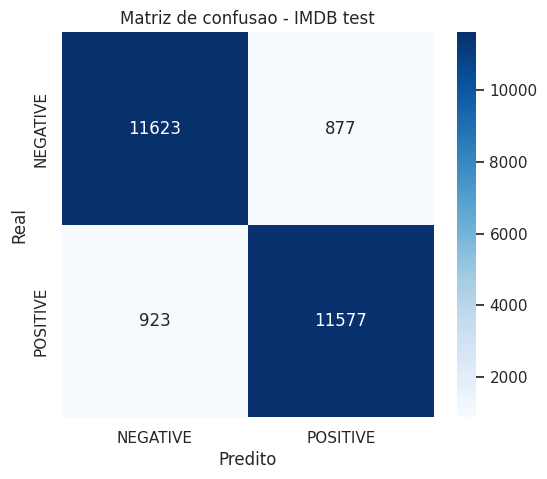

In [10]:
accuracy = accuracy_score(test_df['true_label'], test_df['predicted_label'])
print(f'Acuracia no conjunto de teste completo: {accuracy:.4f}')

labels = ['NEGATIVE', 'POSITIVE']
cm = confusion_matrix(test_df['true_label'], test_df['predicted_label'], labels=labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Matriz de confusao - IMDB test')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

## Distribuicao dos scores

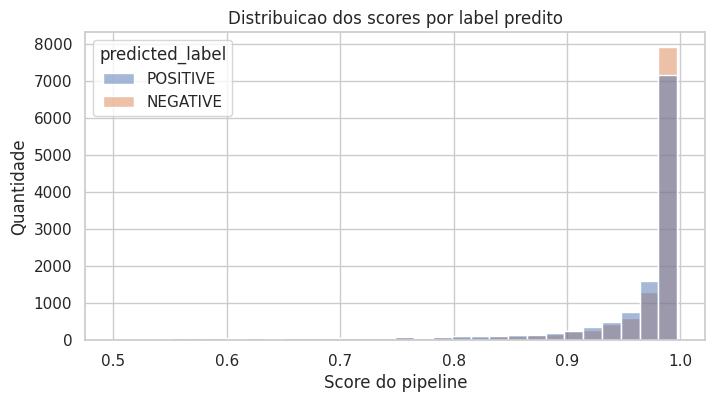

In [11]:
plt.figure(figsize=(8, 4))
sns.histplot(data=test_df, x='score', hue='predicted_label', bins=30, kde=False)
plt.title('Distribuicao dos scores por label predito')
plt.xlabel('Score do pipeline')
plt.ylabel('Quantidade')
plt.show()

## Exemplos de acertos e erros

In [12]:
correct_examples = test_df[test_df['true_label'] == test_df['predicted_label']].head(5)
error_examples = test_df[test_df['true_label'] != test_df['predicted_label']].head(5)

print('Cinco acertos:')
display(correct_examples[['source_file', 'true_label', 'predicted_label', 'score']])

if len(error_examples) > 0:
    print('Ate cinco erros:')
    display(error_examples[['source_file', 'true_label', 'predicted_label', 'score']])
else:
    print('Nao houve erros na avaliacao.')

Cinco acertos:


,source_file,true_label,predicted_label,score
0,test/pos/0_10.txt,POSITIVE,POSITIVE,0.974698
1,test/pos/10000_7.txt,POSITIVE,POSITIVE,0.980706
2,test/pos/10001_9.txt,POSITIVE,POSITIVE,0.979295
3,test/pos/10002_8.txt,POSITIVE,POSITIVE,0.992288
4,test/pos/10003_8.txt,POSITIVE,POSITIVE,0.995468


Ate cinco erros:


,source_file,true_label,predicted_label,score
16,test/pos/10014_7.txt,POSITIVE,NEGATIVE,0.985183
66,test/pos/1005_7.txt,POSITIVE,NEGATIVE,0.611662
69,test/pos/10062_9.txt,POSITIVE,NEGATIVE,0.810788
77,test/pos/1006_8.txt,POSITIVE,NEGATIVE,0.950378
81,test/pos/10073_7.txt,POSITIVE,NEGATIVE,0.757400


## Limitacoes

- O modelo usado ja e pre-treinado; a atividade avalia inferencia, nao treinamento de um transformer.
- Reviews longas sao truncadas em 512 tokens.
- A inferencia em 25000 reviews pode ser lenta sem GPU.
- O resultado depende do modelo escolhido no Hugging Face.
- A acuracia calculada vale para este pipeline e esta configuracao de truncamento.

## Conclusao

O notebook baixou a base IMDB oficial da Stanford, carregou o conjunto de teste completo com 12500 reviews positivas e 12500 negativas, e aplicou a classe `pipeline` da biblioteca Hugging Face `transformers` para classificacao de sentimento.

As predicoes `POSITIVE` e `NEGATIVE` foram comparadas diretamente com os labels reais derivados das pastas `pos` e `neg`. A matriz de confusao, a acuracia e os exemplos de acertos/erros permitem avaliar o comportamento do modelo pre-treinado no dataset indicado pelo enunciado.